In [ ]:

import os
import random
import sqlite3
import textwrap
import uuid
from typing import Any, Dict, List, Optional, TypedDict, Annotated

import requests
import gradio as gr
import nest_asyncio
from dotenv import load_dotenv
from IPython.display import Image, display
from pydantic import BaseModel, Field
from typing_extensions import TypedDict 

# --- LangChain / LangGraph ---
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_core.tools import Tool, tool

from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from langchain_community.tools.playwright.utils import create_async_playwright_browser

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver

In [2]:

nouns = ["Cabbages", "Unicorns", "Toasters", "Penguins", "Bananas", "Zombies", "Rainbows", "Eels", "Pickles", "Muffins"]
adjectives = ["outrageous", "smelly", "pedantic", "existential", "moody", "sparkly", "untrustworthy", "sarcastic", "squishy", "haunted"]

In [3]:
load_dotenv(override=True)

True

In [4]:
def shout(text: Annotated[str, "something to be shouted"]) -> str:
    print(text.upper())
    return text.upper()

shout("hello")

HELLO


'HELLO'

In [5]:

class State(BaseModel):
        
    messages: Annotated[list, add_messages]

In [6]:
graph_builder = StateGraph(State)

In [7]:
def our_first_node(old_state: State) -> State:

    reply = f"{random.choice(nouns)} are {random.choice(adjectives)}"
    messages = [{"role": "assistant", "content": reply}]

    new_state = State(messages=messages)

    return new_state

graph_builder.add_node("first_node", our_first_node)

In [8]:
graph_builder.add_edge(START, "first_node")
graph_builder.add_edge("first_node", END)

In [9]:
graph = graph_builder.compile()

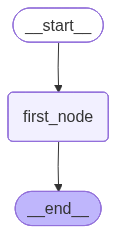

In [10]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
def chat(user_input: str, history):
    message = {"role": "user", "content": user_input}
    messages = [message]
    state = State(messages=messages)
    result = graph.invoke(state)
    print(result)
    return result["messages"][-1].content


gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='b406e53b-4f02-44b8-8393-17cf278fd19b'), AIMessage(content='Penguins are haunted', additional_kwargs={}, response_metadata={}, id='0882509c-43de-4e82-8b68-d03db468b80b', tool_calls=[], invalid_tool_calls=[])]}


In [12]:
class State(BaseModel):
    messages: Annotated[list, add_messages]

In [13]:
graph_builder = StateGraph(State)


In [14]:
class State(BaseModel):
    messages: Annotated[list, add_messages]

In [15]:
llm = ChatOpenAI(model="gpt-4o-mini")

def chatbot_node(old_state: State) -> State:
    response = llm.invoke(old_state.messages)
    new_state = State(messages=[response])
    return new_state

graph_builder.add_node("chatbot", chatbot_node)

In [16]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

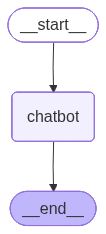

In [17]:
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
def chat(user_input: str, history):
    initial_state = State(messages=[{"role": "user", "content": user_input}])
    result = graph.invoke(initial_state)
    print(result)
    return result['messages'][-1].content


gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7866
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={}, id='672bafd5-cb26-4e3f-830e-3a469bf4823c'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f4ae844694', 'id': 'chatcmpl-D8QqCsnNNS2dzpi1pQo72QKQfYbqL', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c51fe-afcc-7841-bac7-c9c5085432ad-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': 

In [19]:
serper = GoogleSerperAPIWrapper()
serper.run("What is the capital of France?")

'Paris is the capital and largest city of France, with an estimated city population of 2,047,602 in an area of 105.4 km2 (40.7 sq mi), and a metropolitan ... Paris is the capital of France, the largest country of Europe with 550 000 km2 (65 millions inhabitants). Paris has 2.234 million inhabitants end 2011. Paris is the capital and most populous city of France. Situated on the Seine River, in the north of the country, it is in the centre of the Île-de-France ... Paris, city and capital of France, located along the Seine River, in the north-central part of the country. Paris is one of the world\'s most important and ... Paris is the city of romance par excellence, the fashion capital and the best example of French art de vivre. Exploring Paris is an essential rite of passage ... Paris, the capital of France, is often referred to as the "City of Light" and is renowned for its art, culture, and history. PARIS it is the capital and largest city of France. Located on the Seine in the count

In [20]:

tool_search = Tool(
    name="search",
    func=serper.run,
    description="Useful for when you need more information from an online search",
)


In [21]:
tool_search.invoke("What is the capital of France?")

'Paris is the capital and largest city of France, with an estimated city population of 2,047,602 in an area of 105.4 km2 (40.7 sq mi), and a metropolitan ... Paris is the capital of France, the largest country of Europe with 550 000 km2 (65 millions inhabitants). Paris has 2.234 million inhabitants end 2011. Paris is the capital and most populous city of France. Situated on the Seine River, in the north of the country, it is in the centre of the Île-de-France ... The capital of France has been Paris since its liberation in 1944. Paris is the capital city of France, as well as the country\'s largest city. Paris is the city of romance par excellence, the fashion capital and the best example of French art de vivre. Exploring Paris is an essential rite of passage ... PARIS it is the capital and largest city of France. Located on the Seine in the country\'s north, it is a major cultural and political centre of ... Paris is the capital and most populous city of France. Situated on the Seine 

In [22]:
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"

def push(text: str):
    """Send a push notification to the user"""
    requests.post(pushover_url, data = {"token": pushover_token, "user": pushover_user, "message": text})

In [23]:
tool_push = Tool(
        name="send_push_notification",
        func=push,
        description="useful for when you want to send a push notification"
    )

tool_push.invoke("Hello, me")

In [24]:
tools = [tool_search, tool_push]

In [25]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [26]:
graph_builder = StateGraph(State)

In [27]:
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

In [28]:

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

In [ ]:
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")


graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

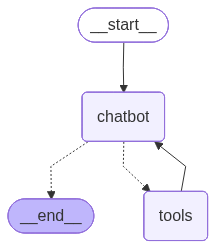

In [30]:
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]})
    return result["messages"][-1].content


gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7868
* To create a public link, set `share=True` in `launch()`.


In [ ]:
memory = MemorySaver()

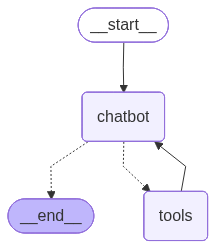

In [ ]:
graph_builder = StateGraph(State)



llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# Step 5
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config = {"configurable": {"thread_id": "1"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7869
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='my name is sai', additional_kwargs={}, response_metadata={}, id='a3d8dac2-6369-4200-8cbb-2dfe7a3ec504')]}
{'messages': [HumanMessage(content='my name is sai', additional_kwargs={}, response_metadata={}, id='a3d8dac2-6369-4200-8cbb-2dfe7a3ec504'), AIMessage(content='Nice to meet you, Sai! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 92, 'total_tokens': 107, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f4ae844694', 'id': 'chatcmpl-D8Qs7lwDM20lWUgUgW2P6H3NitV47', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c5200-8319-7781-9d18-5cf9f2d37403-0', tool_calls=[], invali

In [36]:
graph.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='my name is sai', additional_kwargs={}, response_metadata={}, id='a3d8dac2-6369-4200-8cbb-2dfe7a3ec504'), AIMessage(content='Nice to meet you, Sai! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 92, 'total_tokens': 107, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f4ae844694', 'id': 'chatcmpl-D8Qs7lwDM20lWUgUgW2P6H3NitV47', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c5200-8319-7781-9d18-5cf9f2d37403-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 92, 'output_tokens': 15, 'total_tokens': 107, 'input_token_details': {'a

In [37]:
list(graph.get_state_history(config))

[StateSnapshot(values={'messages': [HumanMessage(content='my name is sai', additional_kwargs={}, response_metadata={}, id='a3d8dac2-6369-4200-8cbb-2dfe7a3ec504'), AIMessage(content='Nice to meet you, Sai! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 92, 'total_tokens': 107, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f4ae844694', 'id': 'chatcmpl-D8Qs7lwDM20lWUgUgW2P6H3NitV47', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c5200-8319-7781-9d18-5cf9f2d37403-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 92, 'output_tokens': 15, 'total_tokens': 107, 'input_token_details': {'

In [ ]:

db_path = "memory.db"
conn = sqlite3.connect(db_path, check_same_thread=False)
sql_memory = SqliteSaver(conn)

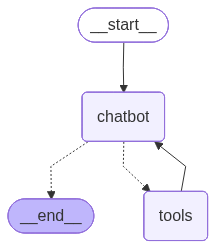

In [ ]:
graph_builder = StateGraph(State)


# Step 3
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))


graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")


graph = graph_builder.compile(checkpointer=sql_memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [41]:
config = {"configurable": {"thread_id": "3"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7870
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='my name is sai', additional_kwargs={}, response_metadata={}, id='479303c7-2317-4ee2-820e-4e73d0894d5e')]}
{'messages': [HumanMessage(content='my name is sai', additional_kwargs={}, response_metadata={}, id='479303c7-2317-4ee2-820e-4e73d0894d5e'), AIMessage(content='Nice to meet you, Sai! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 92, 'total_tokens': 107, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f4ae844694', 'id': 'chatcmpl-D8QtGZMjzmNh8BXlTYKDshahwxtYC', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c5201-9231-7c12-ac25-3c15cd96dce8-0', tool_calls=[], invali

In [43]:
load_dotenv(override=True)

True

In [44]:
class State(TypedDict):
    
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

In [45]:
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"

def push(text: str):
    """Send a push notification to the user"""
    requests.post(pushover_url, data = {"token": pushover_token, "user": pushover_user, "message": text})

tool_push = Tool(
        name="send_push_notification",
        func=push,
        description="useful for when you want to send a push notification"
    )

In [ ]:
nest_asyncio.apply()

async_browser =  create_async_playwright_browser(headless=False)  # headful mode
toolkit = PlayWrightBrowserToolkit.from_browser(async_browser=async_browser)
tools = toolkit.get_tools()

In [48]:
for tool in tools:
    print(f"{tool.name}={tool}")

click_element=async_browser=<Browser type=<BrowserType name=chromium executable_path=/Users/udaykumar/Library/Caches/ms-playwright/chromium-1200/chrome-mac-arm64/Google Chrome for Testing.app/Contents/MacOS/Google Chrome for Testing> version=143.0.7499.4>
navigate_browser=async_browser=<Browser type=<BrowserType name=chromium executable_path=/Users/udaykumar/Library/Caches/ms-playwright/chromium-1200/chrome-mac-arm64/Google Chrome for Testing.app/Contents/MacOS/Google Chrome for Testing> version=143.0.7499.4>
previous_webpage=async_browser=<Browser type=<BrowserType name=chromium executable_path=/Users/udaykumar/Library/Caches/ms-playwright/chromium-1200/chrome-mac-arm64/Google Chrome for Testing.app/Contents/MacOS/Google Chrome for Testing> version=143.0.7499.4>
extract_text=async_browser=<Browser type=<BrowserType name=chromium executable_path=/Users/udaykumar/Library/Caches/ms-playwright/chromium-1200/chrome-mac-arm64/Google Chrome for Testing.app/Contents/MacOS/Google Chrome for Te

In [53]:
tool_dict = {tool.name:tool for tool in tools}

navigate_tool = tool_dict.get("navigate_browser")
extract_text_tool = tool_dict.get("extract_text")
await navigate_tool.arun({"url": "https://lite.cnn.com/"})
text = await extract_text_tool.arun({})
print(text[:2000])


Breaking News, Latest News and Videos | CNN CNN 2/12/2026 Latest Stories Russia says it has blocked WhatsApp amid wider clampdown on social media Guns and mental health struggles: What the apparent online footprint of the Canada school shooter tells us Ireland is paying artists a basic income in a pioneering scheme Zohran Mamdani has big plans for housing, transit…and public bathrooms A ‘Wuthering Heights’ adaptation as shallow as a puddle glittering in the sun Home heating bills are soaring as temperatures plunge. It’s yet another rising cost for Americans Billionaire Manchester United co-owner sparks outrage by claiming UK ‘colonized by immigrants’ Governors association says all members now invited to White House meeting as Trump defends exclusion of some Democrats You might be eligible for free tax prep and filing services The long trip your flowers will make before you can say ‘I love you’ this Valentine’s Day Gisèle Pelicot’s first televised interview: 5 takeaways from the woman w

In [54]:
all_tools = tools + [tool_push]

In [55]:
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(all_tools)


def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

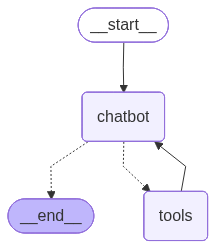

In [56]:
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=all_tools))
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [57]:
config = {"configurable": {"thread_id": "10"}}

async def chat(user_input: str, history):
    result = await graph.ainvoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7871
* To create a public link, set `share=True` in `launch()`.


In [60]:
class EvaluatorOutput(BaseModel):
    feedback: str = Field(description="Feedback on the assistant's response")
    success_criteria_met: bool = Field(description="Whether the success criteria have been met")
    user_input_needed: bool = Field(description="True if more input is needed from the user, or clarifications, or the assistant is stuck")

In [61]:
class State(TypedDict):
    messages: Annotated[List[Any], add_messages]
    success_criteria: str
    feedback_on_work: Optional[str]
    success_criteria_met: bool
    user_input_needed: bool

In [73]:
worker_llm = ChatOpenAI(model="gpt-4o-mini")
worker_llm_with_tools = worker_llm.bind_tools(tools)

evaluator_llm = ChatOpenAI(model="gpt-4o-mini")
evaluator_llm_with_output = evaluator_llm.with_structured_output(EvaluatorOutput)

In [ ]:


def worker(state: State) -> Dict[str, Any]:
    system_message = f"""You are a helpful assistant that can use tools to complete tasks.
You keep working on a task until either you have a question or clarification for the user, or the success criteria is met.
This is the success criteria:
{state['success_criteria']}
You should reply either with a question for the user about this assignment, or with your final response.
If you have a question for the user, you need to reply by clearly stating your question. An example might be:

Question: please clarify whether you want a summary or a detailed answer

If you've finished, reply with the final answer, and don't ask a question; simply reply with the answer.
"""
    
    if state.get("feedback_on_work"):
        system_message += f"""
Previously you thought you completed the assignment, but your reply was rejected because the success criteria was not met.
Here is the feedback on why this was rejected:
{state['feedback_on_work']}
With this feedback, please continue the assignment, ensuring that you meet the success criteria or have a question for the user."""
    
    # Add in the system message

    found_system_message = False
    messages = state["messages"]
    for message in messages:
        if isinstance(message, SystemMessage):
            message.content = system_message
            found_system_message = True
    
    if not found_system_message:
        messages = [SystemMessage(content=system_message)] + messages
    
   
    response = worker_llm_with_tools.invoke(messages)
    
    return {
        "messages": [response],
    }
    

In [75]:
def worker_router(state: State) -> str:
    last_message = state["messages"][-1]
    
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    else:
        return "evaluator"

In [76]:
def format_conversation(messages: List[Any]) -> str:
    conversation = "Conversation history:\n\n"
    for message in messages:
        if isinstance(message, HumanMessage):
            conversation += f"User: {message.content}\n"
        elif isinstance(message, AIMessage):
            text = message.content or "[Tools use]"
            conversation += f"Assistant: {text}\n"
    return conversation

In [77]:
def evaluator(state: State) -> State:
    last_response = state["messages"][-1].content

    system_message = """You are an evaluator that determines if a task has been completed successfully by an Assistant.
Assess the Assistant's last response based on the given criteria. Respond with your feedback, and with your decision on whether the success criteria has been met,
and whether more input is needed from the user."""
    
    user_message = f"""You are evaluating a conversation between the User and Assistant. You decide what action to take based on the last response from the Assistant.

The entire conversation with the assistant, with the user's original request and all replies, is:
{format_conversation(state['messages'])}

The success criteria for this assignment is:
{state['success_criteria']}

And the final response from the Assistant that you are evaluating is:
{last_response}

Respond with your feedback, and decide if the success criteria is met by this response.
Also, decide if more user input is required, either because the assistant has a question, needs clarification, or seems to be stuck and unable to answer without help.
"""
    if state["feedback_on_work"]:
        user_message += f"Also, note that in a prior attempt from the Assistant, you provided this feedback: {state['feedback_on_work']}\n"
        user_message += "If you're seeing the Assistant repeating the same mistakes, then consider responding that user input is required."
    
    evaluator_messages = [SystemMessage(content=system_message), HumanMessage(content=user_message)]

    eval_result = evaluator_llm_with_output.invoke(evaluator_messages)
    new_state = {
        "messages": [{"role": "assistant", "content": f"Evaluator Feedback on this answer: {eval_result.feedback}"}],
        "feedback_on_work": eval_result.feedback,
        "success_criteria_met": eval_result.success_criteria_met,
        "user_input_needed": eval_result.user_input_needed
    }
    return new_state

In [78]:
def route_based_on_evaluation(state: State) -> str:
    if state["success_criteria_met"] or state["user_input_needed"]:
        return "END"
    else:
        return "worker"

In [ ]:
graph_builder = StateGraph(State)

graph_builder.add_node("worker", worker)
graph_builder.add_node("tools", ToolNode(tools=tools))
graph_builder.add_node("evaluator", evaluator)

graph_builder.add_conditional_edges("worker", worker_router, {"tools": "tools", "evaluator": "evaluator"})
graph_builder.add_edge("tools", "worker")
graph_builder.add_conditional_edges("evaluator", route_based_on_evaluation, {"worker": "worker", "END": END})
graph_builder.add_edge(START, "worker")

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

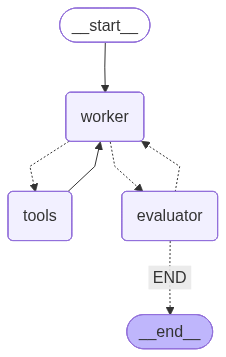

In [80]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
def make_thread_id() -> str:
    return str(uuid.uuid4())

async def process_message(message, success_criteria, history, thread):
    # history must always be a list
    history = history or []

    config = {"configurable": {"thread_id": thread}}
    state = {
        "messages": message,  # keep as-is if your graph expects a string
        "success_criteria": success_criteria,
        "feedback_on_work": None,
        "success_criteria_met": False,
        "user_input_needed": False,
    }

    result = await graph.ainvoke(state, config=config)

    reply_text = result["messages"][-2].content
    feedback_text = result["messages"][-1].content

    history = history + [
        {"role": "user", "content": message},
        {"role": "assistant", "content": reply_text},
        {"role": "assistant", "content": feedback_text},
    ]
    return history

async def reset():
    # chatbot history must be []
    return "", "", [], make_thread_id()

theme = gr.themes.Default(primary_hue="emerald")

with gr.Blocks() as demo:
    gr.Markdown("## Sidekick Personal Co-worker")
    thread = gr.State(make_thread_id())

    # IMPORTANT: type="messages" because we return dict messages
    chatbot = gr.Chatbot(label="Sidekick", height=300, value=[])

    message = gr.Textbox(show_label=False, placeholder="Your request to your sidekick")
    success_criteria = gr.Textbox(show_label=False, placeholder="What are your success criteria?")

    with gr.Row():
        reset_button = gr.Button("Reset", variant="stop")
        go_button = gr.Button("Go!", variant="primary")

    message.submit(process_message, [message, success_criteria, chatbot, thread], [chatbot])
    go_button.click(process_message, [message, success_criteria, chatbot, thread], [chatbot])
    reset_button.click(reset, [], [message, success_criteria, chatbot, thread])

# debug/show_error will print the real traceback if something else fails
demo.launch(theme=theme, debug=True, show_error=True, inline=False)



* Running on local URL:  http://127.0.0.1:7874
* To create a public link, set `share=True` in `launch()`.
Keyboard interruption in main thread... closing server.
